# PS-S5E12: XGBoost

This notebook tackles the [**Playground Series – Season 5, Episode 12: Diabetes Prediction Challenge**](https://www.kaggle.com/competitions/playground-series-s5e12), a competition focused on aiding medical diagnosis: predict if a patient will be diagnosed with diabetes.  The goal is to develop a model that can accurately predict whether a patient will be diagnosed with diabetes, based on a set of medical and demographic features.

## Introduction

**XGBoost** is highly effective at capturing non-linear relationships between physiological markers (like BMI and Blood Pressure) and the target. It handles missing values internally (if any exist) and includes regularization (L1/L2) to prevent overfitting on smaller datasets.
We will need to encode our categorical variables (One-Hot or Label Encoding) before feeding them into XGBoost, as it treats inputs as numerical matrices.
The notebook is one of a number of notebooks that explore various models to address this challenge.  The EDA for this dataset was performed in this notebook: [**PS-S5E12: EDA**](https://www.kaggle.com/code/stephentarter/ps-s5e12-eda).

## Install Needed Packages

In [1]:
%load_ext autoreload
%autoreload 2
    
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler # Import this
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from diabetes_preprocessing import FeatureFactory
from model_visualizer import ModelVisualizer
from experiment_setup import ExperimentSetup

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'diagnosed_diabetes'

# Show GPU be utilized in training
USE_GPU = False

# Recursive Feature Elimination should be performed in the pipeline.
PERFORM_RFE = False

# Optuna tuning should be performed in the pipeline
PERFORM_OPTUNA_TUNING = False

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [3]:
training_df = helper.read_training_dataset()

TRAINING DATASET

   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  systolic_bp  diastolic_bp  heart_rate  \
0   

## Read and Examine the Test Dataset

In [4]:
test_df = helper.read_test_dataset()

TEST DATASET

       id  age  alcohol_consumption_per_week  \
0  700000   45                             4   
1  700001   35                             1   
2  700002   45                             1   
3  700003   55                             2   
4  700004   77                             2   

   physical_activity_minutes_per_week  diet_score  sleep_hours_per_day  \
0                                 100       4.300                6.800   
1                                  87       3.500                4.600   
2                                  61       7.600                6.800   
3                                  81       7.300                7.300   
4                                  29       7.300                7.600   

   screen_time_hours_per_day    bmi  waist_to_hip_ratio  systolic_bp  \
0                      6.200 25.500               0.840          123   
1                      9.000 28.600               0.880          120   
2                      7.000 28.500 

## Feature Engineering

In [5]:
# Define which strategies to use for the XGBoost model here:
fe_strategies = [
    'drop_id',
    'ordinal_encoding',
    'medical_metrics',
    'clinical_indices',
    'interactions',
    'ratios',
    'log',
    'binning',
    'cohort_deviations',
    'clustering'
]

In [6]:
print('Performing initial feature engineering.')

# Get the target before we start messing with features
y = training_df[TARGET]

# Initialize and apply the feature factory
feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Fit_transform on training, transform on test
X_full = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

X = X_full.drop(TARGET, axis=1, errors='ignore')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 25
New Feature Count: 44
   age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   31                             1                                  45   
1   50                             2                                  73   
2   32                             3                                 158   
3   54                             3                                  77   
4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day    bmi  \
0       7.700                6.800                      6.100 33.400   
1       5.700                6.500                      5.800 23.800   
2       8.500                7.400                      9.100 24.100   
3       4.600                7.000                      9.200 26.600   
4       5.700                6.200                      5.100 28.800   

   waist_to_hip_ratio  sys

## Optional Recursive Feature Elimination and Optuna Training

If the `PERFORM_RFE` variable in cell 3 is set to True, Recursive Feature Elimination (RFE) is performed.  This works by training the model, identifying the weakest feature, deleting it, and then re-training. It repeats this process until it finds the exact subset of features that gives the highest Cross-Validation score.  This step is performed on a temporary feature engineered dataset to determine the optimal set of features, which are used to filter the in-fold feature engineered dataset.  If the variable is set to False, all features are used in training.

If the `PERFORM_OPTUNA_TUNING` variable in cell 3 is set to True, an Optuna trial is performed to determine the best set of hyperscaling parameters.  If training isn't requested, a set of hyperparameters derived from an earlier run is used instead.

Running Recursive Feature Elimination (this will take a few minutes)...
Optimal number of features: 21


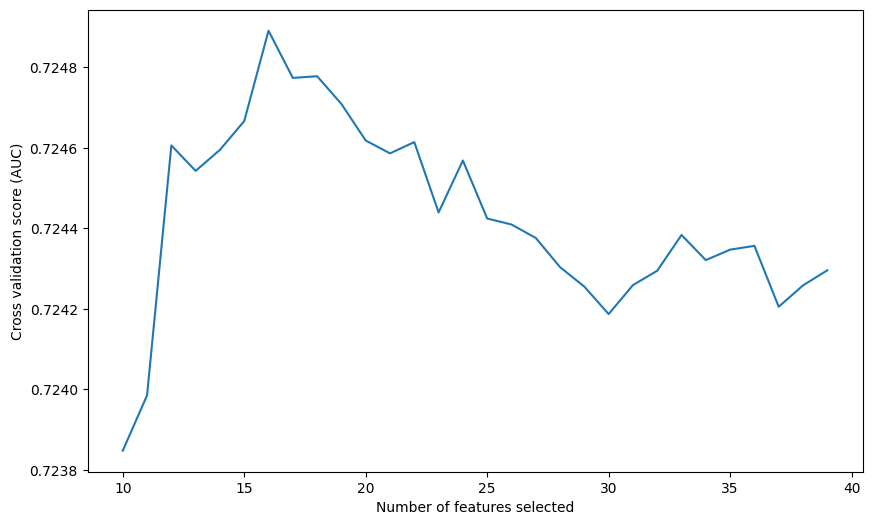


Optimal Features:
['age', 'physical_activity_minutes_per_week', 'diet_score', 'waist_to_hip_ratio', 'systolic_bp', 'heart_rate', 'cholesterol_total', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'cardiovascular_history', 'non_hdl_cholesterol', 'vai_proxy', 'lap_proxy', 'age_bmi_interaction', 'sedentary_ratio', 'cholesterol_risk_ratio', 'whr_bmi_product', 'triglycerides_log', 'age_decile', 'bmi_dev_from_cohort']


In [7]:
n_jobs = 1 if USE_GPU else -1

# Convert object columns to 'category' dtype
X_rfe = X.copy()

# Identify string/object columns
cat_cols = X_rfe.select_dtypes(include=['object', 'category']).columns.tolist()

if cat_cols:
    # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_rfe[cat_cols] = oe.fit_transform(X_rfe[cat_cols])
    
    # Ensure they are cast to integer type for XGBoost
    # We cast to 'category' type so XGBoost knows to treat them as discrete
    for col in cat_cols:
        X_rfe[col] = X_rfe[col].astype('category')
        
if PERFORM_RFE:    
    # Suppress the specific XGBoost warning to clean up the output
    warnings.filterwarnings('ignore', message='.*Falling back to prediction using DMatrix.*')
    
    # Use a "stfe" set of parameters
    rfe_params = {
        'n_estimators': 1000,
        'learning_rate': 0.05,
        'max_depth': 6,          # Standard starting depth
        'colsample_bytree': 0.8, # Allow it to see most features
        'reg_alpha': 0.1,        # Light regularization only
        'device': 'cuda',
        'tree_method': 'hist',
        'enable_categorical': True
    }
    
    # 'gpu_hist' is removed. Now we use 'hist' + device='cuda'
    if USE_GPU:
        rfe_params['device'] = 'cuda'
    else:
        rfe_params['device'] = 'cpu'
    
    # Setup Model with Best Params
    # We use the exact same params that found the signal in the noise
    clf = xgb.XGBClassifier(**rfe_params)

    # Initialize RFECV
    # step=1: remove 1 feature at a time (most precise)
    # min_features_to_select=10: Don't go below 10 features
    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=seed),
        scoring='roc_auc',
        min_features_to_select=15,
        n_jobs=n_jobs,
        verbose=0
    )
    
    print('Running Recursive Feature Elimination (this will take a few minutes)...')
    rfecv.fit(X_rfe, y)
    
    # Results
    print(f'Optimal number of features: {rfecv.n_features_}')
    
    # Plot Performance vs Number of Features
    # Note: usage of cv_results_ depends on sklearn version, this is for recent versions
    n_scores = len(rfecv.cv_results_['mean_test_score'])
    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross validation score (AUC)')
    plt.plot(
        range(10, 10 + n_scores),
        rfecv.cv_results_['mean_test_score']
    )
    plt.show()

    # Save the selected features for the next step
    optimal_cols = X_rfe.columns[rfecv.support_]
else:
    print('Using columns from a previous RFE as optimal features.')
    optimal_cols = pd.Index([
        'age',
        'physical_activity_minutes_per_week',
        'diet_score',
        'waist_to_hip_ratio',
        'systolic_bp',
        'heart_rate',
        'cholesterol_total',
        'ldl_cholesterol',
        'triglycerides',
        'family_history_diabetes',
        'cardiovascular_history',
        'non_hdl_cholesterol',
        'vai_proxy',
        'lap_proxy', 
        'age_bmi_interaction',
        'sedentary_ratio',
        'cholesterol_risk_ratio',
        'whr_bmi_product',
        'triglycerides_log',
        'age_decile',
        'bmi_dev_from_cohort'
    ])
    X_rfe.columns
    
print('\nOptimal Features:')
print(optimal_cols.tolist())

### Addressing Data Distribution Shift: Synthetic vs. Original Data

[Recent community findings](https://www.kaggle.com/code/masayakawamata/s5e12-xgb-bridging-the-cv-lb-gap) have identified a significant distribution shift within the training dataset. Specifically, the data appears to be split into two distinct segments:
*   **Synthetic Data:** Records from index 0 to 678,259 generated by a deep learning model.
*   **Original Data:** Records from index 678,260 to the end, representing real-world patient data.

Crucially, the **Test Set** (Public Leaderboard) closely follows the distribution of the **Original Data**.

**Impact on Training Strategy**
`
To bridge the gap between Cross-Validation (CV) scores and the Public Leaderboard (LB), we cannot simply use a standard K-Fold split across the entire dataset. Doing so would validate the model primarily on synthetic patterns, which may not generalize to the real-world test data.

The Solution: "Bridging" Validation Scheme

We have modified the training pipeline to implement a custom validation strategy:
1.  **Split the Train Data:** We explicitly separate the dataset into Synthetic and Original subsets based on the index 678,260.
2.  **Original-Only Validation:** The K-Fold splitter is applied **only** to the Original Data indices.
3.  **Hybrid Training Sets:** For every fold `k`:
    *   **Validation Set:** The $k$-th fold of the Original Data.
    *   **Training Set:** All Synthetic Data + the remaining `(k-1)` folds of the Original Data.

This ensures that our CV metric reflects performance on real data (like the LB), while still leveraging the massive volume of synthetic data for regularization and learning complex feature interactions.

**Additional Adjustments:**
*   **Sample Weights:** We apply higher sample weights (2.0) to the Original Data rows during training to force the model to prioritize real patterns over synthetic artifacts.
*   **Categorical Encoding:** We ensure consistent OrdinalEncoding and type casting to category for all object columns (e.g., Gender, Ethnicity) to fully utilize LightGBM's native categorical handling capabilities.

In [8]:
# A split in the data has been described here: https://www.kaggle.com/code/masayakawamata/s5e12-xgb-bridging-the-cv-lb-gap
# This is the index identified above; we'll use it to split the data
ORIGINAL_START_INDEX = 678260

# Determine the ratio of true/false in the target for use in scale_pos_weight below
neg = (y == 0).sum()
pos = (y == 1).sum()
base_ratio = neg / pos
print(f'Ratio of neg/pos in the target is {base_ratio}')

def objective(trial):
    
    # Suggest Parameters
    param = {
        # Core Booster Params
        'n_estimators': 10000,              # Give it room to run, let early stopping cut it
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 5.0, 50.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
        
        # Regularization (Expanded ranges)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),  # L1 Reg
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # L2 Reg
        'gamma': trial.suggest_float('gamma', 0.1, 5.0),
        
        # Tree Structure & Imbalance
        'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']),
        # Helps with class imbalance (approx ratio of negatives/positives)
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight',
            0.5 * base_ratio,
            1.5 * base_ratio
        ),  
        
        # Boilerplate
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'tree_method': 'gpu_hist' if USE_GPU else 'hist',
        'enable_categorical': True,
        'early_stopping_rounds': 50,
        'random_state': seed,
        'n_jobs': n_jobs
    }

    # Ensure optimal_cols is a standard list for filtering
    # (Handling cases where it might be a pandas Index or numpy array)
    cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols
    
    # Separate Synthetic and Original Indices
    synthetic_mask = training_df.index < ORIGINAL_START_INDEX
    original_mask = training_df.index >= ORIGINAL_START_INDEX
    
    # Indices for synthetic data (Always used in Training)
    synth_indices = training_df[synthetic_mask].index.to_numpy()
    
    # Indices for original data (Used for CV splitting)
    orig_indices = training_df[original_mask].index.to_numpy()
    orig_targets = y[original_mask] # Needed for stratification
    
    # Initialize CV on Original Data ONLY
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    oof_preds = np.zeros(len(y)) # Keep full size for compatibility, but only fill original
    test_preds = np.zeros(len(test_df))

    # Custom Loop
    # We split ONLY the original indices
    for fold, (train_idx_orig_relative, val_idx_orig_relative) in enumerate(skf.split(orig_indices, orig_targets)):
        
        # Map relative indices back to global dataframe indices
        global_train_orig_idx = orig_indices[train_idx_orig_relative]
        global_val_orig_idx = orig_indices[val_idx_orig_relative]
        
        # CONSTRUCT TRAINING SET: All Synthetic + (K-1) Original Folds
        final_train_idx = np.concatenate([synth_indices, global_train_orig_idx])
        
        # CONSTRUCT VALIDATION SET: Just the K-th Original Fold
        final_val_idx = global_val_orig_idx
        
        # Fill fold for training and validation using the indices we just constructed.
        X_train_fold = training_df.iloc[final_train_idx]
        y_train_fold = y.iloc[final_train_idx]
        
        X_val_fold = training_df.iloc[final_val_idx]
        y_val_fold = y.iloc[final_val_idx]
        
        # Feature Engineering (Per fold to prevent leakage)
        fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
        
        X_train_trans = fe_fold.fit_transform(X_train_fold)
        X_val_trans = fe_fold.transform(X_val_fold)

        # Create Sample Weights. Initialize weights as 1.0
        train_weights = np.ones(len(X_train_fold))
        
        # Identify indices that belong to the Original Dataset within the current training fold
        num_synth = len(synth_indices)
        
        # Everything after num_synth is Original data. Assign higher weight (e.g., 2.0 or 3.0)
        train_weights[num_synth:] = 2.0

        # Restrict to optimal column set
        if cols_to_keep is not None:
            final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
            if not final_cols:
                # If this ever happens in tuning, you'd rather fail fast
                raise RuntimeError("No overlap between optimal_cols and fold feature columns.")
            X_train_trans = X_train_trans[final_cols]
            X_val_trans   = X_val_trans[final_cols]
        
        # Identify categorical columns for CatBoost
        cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # Ensure categorical columns are type 'category' (XGBoost-friendly)
        if cat_cols:
            for c in cat_cols:
                X_train_trans[c] = X_train_trans[c].astype('category')
                X_val_trans[c]   = X_val_trans[c].astype('category')
            
        # Create model
        model = xgb.XGBClassifier(**param)

        # Train the model
        model.fit(
            X_train_trans, y_train_fold,
            sample_weight=train_weights,
            eval_set=[(X_val_trans, y_val_fold), (X_train_trans, y_train_fold)],
            verbose=False
        )
        
        # Store OOF predictions (Only for the validation rows)
        val_probs = model.predict_proba(
            X_val_trans,
            iteration_range=(0, model.best_iteration + 1)
        )[:, 1]
        oof_preds[final_val_idx] = val_probs
        
        # Score this fold
        fold_auc = roc_auc_score(y_val_fold, val_probs)

    # Final Metric Calculation
    # ONLY calculate score on the original data indices
    final_valid_mask = oof_preds != 0 
    original_data_auc = roc_auc_score(y[original_mask], oof_preds[original_mask])
    
    return np.mean(original_data_auc)

Ratio of neg/pos in the target is 0.6043749011590462


In [9]:
if PERFORM_OPTUNA_TUNING:
    # Run Optimization
    sampler = TPESampler(seed=seed)
    
    study = optuna.create_study(
        study_name='xgb_diabetes_prediction_optuna', 
        direction='maximize',
        sampler=sampler
    )
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print('Best Params:', study.best_params)
    print('Best AUC:', study.best_value)

    best_params = study.best_params
else:
    # Values from earlier tuning
    best_params = {
        'learning_rate': 0.010820301555897324,
        'max_depth': 4,
        'min_child_weight': 24.235480308763414,
        'subsample': 0.6812507133930776,
        'colsample_bytree': 0.5112951606320921,
        'reg_alpha': 1.0177921901853053,
        'reg_lambda': 4.769005314702786,
        'gamma': 1.7340740227498168,
        'grow_policy': 'depthwise',
        'scale_pos_weight': 0.5325011845353228
    }

[I 2025-12-29 11:15:05,782] A new study created in memory with name: xgb_diabetes_prediction_optuna


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-29 11:23:00,326] Trial 0 finished with value: 0.6987948469729932 and parameters: {'learning_rate': 0.027602609060648257, 'max_depth': 5, 'min_child_weight': 40.924758098651324, 'subsample': 0.7257087610519434, 'colsample_bytree': 0.6389391005441778, 'reg_alpha': 1.1448758024911176, 'reg_lambda': 9.746437376742904, 'gamma': 3.3575141594678635, 'grow_policy': 'depthwise', 'scale_pos_weight': 0.6630475480415252}. Best is trial 0 with value: 0.6987948469729932.
[I 2025-12-29 11:41:45,048] Trial 1 finished with value: 0.6975436719775374 and parameters: {'learning_rate': 0.016454039171287464, 'max_depth': 7, 'min_child_weight': 25.10856813115689, 'subsample': 0.5056098911648722, 'colsample_bytree': 0.8558141006136075, 'reg_alpha': 0.35382830316192654, 'reg_lambda': 0.05924906068160358, 'gamma': 2.616009762014503, 'grow_policy': 'lossguide', 'scale_pos_weight': 0.3230379177337937}. Best is trial 0 with value: 0.6987948469729932.
[I 2025-12-29 13:29:34,650] Trial 2 finished with val

## Model Training

In [10]:
# Cross-Validation Training Loop

xgb_tuned_params = {
    **best_params,
    'n_estimators': 12000,    # High iterations have been observed; giving it room
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'n_jobs': n_jobs,
    'random_state': seed,
    'early_stopping_rounds': 50,
    'tree_method': 'gpu_hist' if USE_GPU else None,
    'enable_categorical': True,
}

print('Final XGBoost CV Training with OOF / Test predictions')
print('======================================================')
print('Parameters used for training:')
print(xgb_tuned_params)

# Ensure optimal_cols is a standard list for filtering
# (Handling cases where it might be a pandas Index or numpy array)
cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Separate Synthetic and Original Indices
synthetic_mask = training_df.index < ORIGINAL_START_INDEX
original_mask = training_df.index >= ORIGINAL_START_INDEX

# Indices for synthetic data (Always used in Training)
synth_indices = training_df[synthetic_mask].index.to_numpy()

# Indices for original data (Used for CV splitting)
orig_indices = training_df[original_mask].index.to_numpy()
orig_targets = y[original_mask] # Needed for stratification

# Initialize CV on Original Data ONLY
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

print(f"Training on {len(synth_indices)} synthetic rows + Original Data Folds")
print(f"Validating strictly on {len(orig_indices)} original rows")
print(' ')

# Storage for plotting later
eval_results = []
models = []

# Arrays to store results
oof_preds = np.zeros(len(y)) # Keep full size for compatibility, but only fill original
test_preds = np.zeros(len(test_df))

# Custom Loop
# We split ONLY the original indices
for fold, (train_idx_orig_relative, val_idx_orig_relative) in enumerate(skf.split(orig_indices, orig_targets)):

    print(f"Starting processing of fold {fold+1}")

    # Map relative indices back to global dataframe indices
    global_train_orig_idx = orig_indices[train_idx_orig_relative]
    global_val_orig_idx = orig_indices[val_idx_orig_relative]
    
    # CONSTRUCT TRAINING SET: All Synthetic + (K-1) Original Folds
    final_train_idx = np.concatenate([synth_indices, global_train_orig_idx])
    
    # CONSTRUCT VALIDATION SET: Just the K-th Original Fold
    final_val_idx = global_val_orig_idx
    
    # Fill fold for training and validation using the indices we just constructed.
    X_train_fold = training_df.iloc[final_train_idx]
    y_train_fold = y.iloc[final_train_idx]
    
    X_val_fold = training_df.iloc[final_val_idx]
    y_val_fold = y.iloc[final_val_idx]
    
    # Feature Engineering (Per fold to prevent leakage)
    fe_fold = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)
    
    X_train_trans = fe_fold.fit_transform(X_train_fold)
    X_val_trans = fe_fold.transform(X_val_fold)
    X_test_trans = fe_fold.transform(test_df)
    
    # Create Sample Weights. Initialize weights as 1.0
    train_weights = np.ones(len(X_train_fold))
    
    # Identify indices that belong to the Original Dataset within the current training fold
    num_synth = len(synth_indices)
    
    # Everything after num_synth is Original data. Assign higher weight (e.g., 2.0 or 3.0)
    train_weights[num_synth:] = 2.0

    # Restrict to optimal column set
    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError("No overlap between optimal_cols and fold feature columns.")
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]
        X_test_trans  = X_test_trans[final_cols]

    cat_cols = X_train_trans.select_dtypes(include=['object', 'category']).columns.tolist()

    if cat_cols:
        # Use OrdinalEncoder to turn "Female" -> 0, "Male" -> 1
        oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X_train_trans[cat_cols] = oe.fit_transform(X_train_trans[cat_cols])
        X_val_trans[cat_cols] = oe.transform(X_val_trans[cat_cols])
        X_test_trans[cat_cols] = oe.transform(X_test_trans[cat_cols])

        # Ensure they are cast to integer type for XGBoost
        # We cast to 'category' type so XGBoost knows to treat them as discrete
        for col in cat_cols:
            X_train_trans[col] = X_train_trans[col].astype('category')
            X_val_trans[col] = X_val_trans[col].astype('category')
            X_test_trans[col] = X_test_trans[col].astype('category')
        
    # Create model
    # Note: We are fitting the preprocessor every fold. 
    model = xgb.XGBClassifier(**xgb_tuned_params)
    
    # Train Model
    # The pipeline will call feature_factory.fit_transform(X_train)
    # and then pass that result to xgb.fit()
    model.fit(
        X_train_trans, y_train_fold,
        sample_weight=train_weights,
        eval_set=[(X_val_trans, y_val_fold), (X_train_trans, y_train_fold)],
        verbose=100
    )
    
    # Store history for this fold
    eval_results.append(model.evals_result())
    models.append(model)
    
    # Store OOF predictions (Only for the validation rows)
    val_probs = model.predict_proba(
        X_val_trans,
        iteration_range=(0, model.best_iteration + 1)
    )[:, 1]
    oof_preds[final_val_idx] = val_probs
    
    # Score this fold
    fold_auc = roc_auc_score(y_val_fold, val_probs)
    print(f"Fold {fold+1} Original-Data AUC: {fold_auc:.5f} (best_iteration={model.best_iteration})")
    
    # Accumulate Test Preds
    test_probs = model.predict_proba(
        X_test_trans,
        iteration_range=(0, model.best_iteration + 1)
    )[:, 1]
    test_preds += test_probs / 5 # n_splits
    
# Final Metric Calculation
# ONLY calculate score on the original data indices
final_valid_mask = oof_preds != 0 # 
original_data_auc = roc_auc_score(y[original_mask], oof_preds[original_mask])
print(f"\nOverall CV AUC (Original Data Only): {original_data_auc:.5f}")    

Final XGBoost CV Training with OOF / Test predictions
Parameters used for training:
{'learning_rate': 0.010820301555897324, 'max_depth': 4, 'min_child_weight': 24.235480308763414, 'subsample': 0.6812507133930776, 'colsample_bytree': 0.5112951606320921, 'reg_alpha': 1.0177921901853053, 'reg_lambda': 4.769005314702786, 'gamma': 1.7340740227498168, 'grow_policy': 'depthwise', 'scale_pos_weight': 0.5325011845353228, 'n_estimators': 12000, 'objective': 'binary:logistic', 'eval_metric': 'auc', 'n_jobs': 1, 'random_state': 10301, 'early_stopping_rounds': 50, 'tree_method': 'gpu_hist', 'enable_categorical': True}
Training on 678260 synthetic rows + Original Data Folds
Validating strictly on 21740 original rows
 
Starting processing of fold 1
[0]	validation_0-auc:0.66283	validation_1-auc:0.67809
[100]	validation_0-auc:0.67963	validation_1-auc:0.69488
[200]	validation_0-auc:0.68233	validation_1-auc:0.69896
[300]	validation_0-auc:0.68589	validation_1-auc:0.70330
[400]	validation_0-auc:0.68817	val

## Visualize the Quality of Training

It is standard practice to visualize Learning Curves (to spot overfitting/underfitting) and the ROC Curve (to check classification performance).

### Learning Curves (Train vs. Validation AUC)

**Definition**  
This graph plots the model's performance (AUC) on the y-axis against the number of boosting rounds (iterations) on the x-axis. It displays two lines:
*   **Blue (Train):** How well the model learned the data it has already seen.
*   **Red (Validation):** How well the model generalizes to new data it hasn't seen.

**Interpretation**  
This graph is fairly easy to interpret, and is a powerful indicator of how the model is likely to perform on new data.
*   **Ideal:** Both lines go up steeply and plateau. The Blue line is slightly higher than the Red line, but the gap is stable.
*   **Overfitting:** The Blue line keeps going up (approaching 1.0), but the Red line flattens out early or starts dropping. The "gap" between them widens significantly.
*   **Underfitting:** Both lines flatten out very early at a low score. The model is too simple to learn the patterns.

**Actions for Overfitting**  
If the Training score is 0.95 but the validation score is 0.72, the  are overfitting.
1.  **Restrict Depth:** Reduce `max_depth` (e.g., from 6 to 3 or 4). This forces the model to learn simpler, more general rules.
2.  **Add Randomness:** Lower `subsample` and `colsample_bytree` (e.g., to 0.6). This prevents the model from relying too heavily on specific rows or features.
3.  **Increase Regularization:** Increase `reg_alpha` (L1) or `reg_lambda` (L2). This penalizes the model for becoming too complex.
4.  **Increase `min_child_weight`:** This prevents the tree from creating leaves that only apply to a tiny handful of patients (noise).

In [11]:
xgb_tuned_params

{'learning_rate': 0.010820301555897324,
 'max_depth': 4,
 'min_child_weight': 24.235480308763414,
 'subsample': 0.6812507133930776,
 'colsample_bytree': 0.5112951606320921,
 'reg_alpha': 1.0177921901853053,
 'reg_lambda': 4.769005314702786,
 'gamma': 1.7340740227498168,
 'grow_policy': 'depthwise',
 'scale_pos_weight': 0.5325011845353228,
 'n_estimators': 12000,
 'objective': 'binary:logistic',
 'eval_metric': 'auc',
 'n_jobs': 1,
 'random_state': 10301,
 'early_stopping_rounds': 50,
 'tree_method': 'gpu_hist',
 'enable_categorical': True}

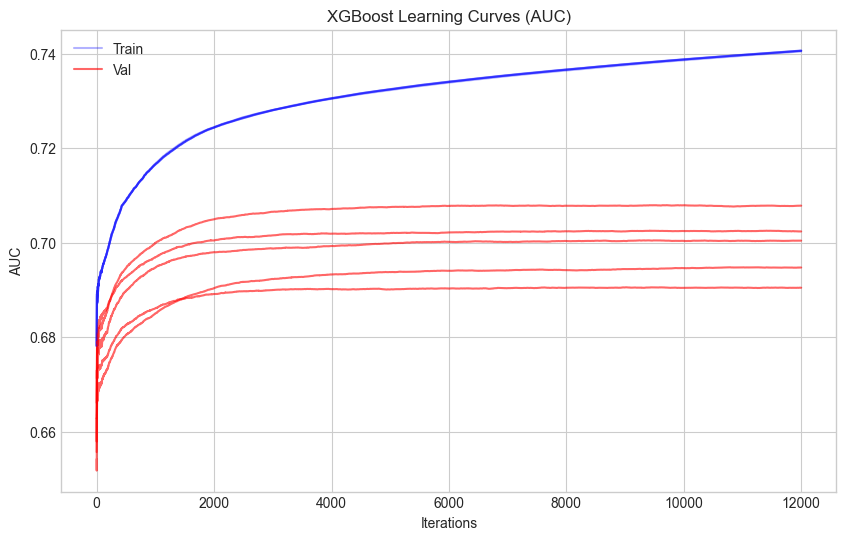

In [12]:
mviz = ModelVisualizer(model_name='XGBoost')

mviz.plot_learning_curves(eval_results)

### Feature Importance (Gain)

This chart ranks features by how much they improved the model's accuracy (reduced the loss function) whenever they were used in a split.

**Interpretation**  
*   **High Gain:** These are the "Signal" features. The model relies on them heavily.
*   **Low/Zero Gain:** These features were rarely useful. The model mostly ignored them.

**What if engineered features aren't at the top?**  
*   **Don't Panic:** It's okay if raw features like Glucose or BMI are still top. They are strong predictors!
*   **Check Correlations:** If BMI is #1 and your engineered BMI\_Ratio is #50, they might be highly correlated, and the model just chose the simpler one. This is fine.
*   **Re-evaluate:** If an engineered feature is at the very bottom (0 importance), it failed. The hypothesis behind it (e.g., "Age \* Height") likely has no biological relevance.

**What to do with Low Performing Features**  
*   **Zero Importance:** **Drop them.** They add computational cost and noise without adding value.
*   **Low Importance:**  
    *   **Try Dropping:** Sometimes removing "noise" features helps the model focus on the signal (increases score).
  
    *   **Combine Them:** If SkinThickness is weak on its own, try creating an interaction like Insulin / SkinThickness. Sometimes two weak features make one strong feature.

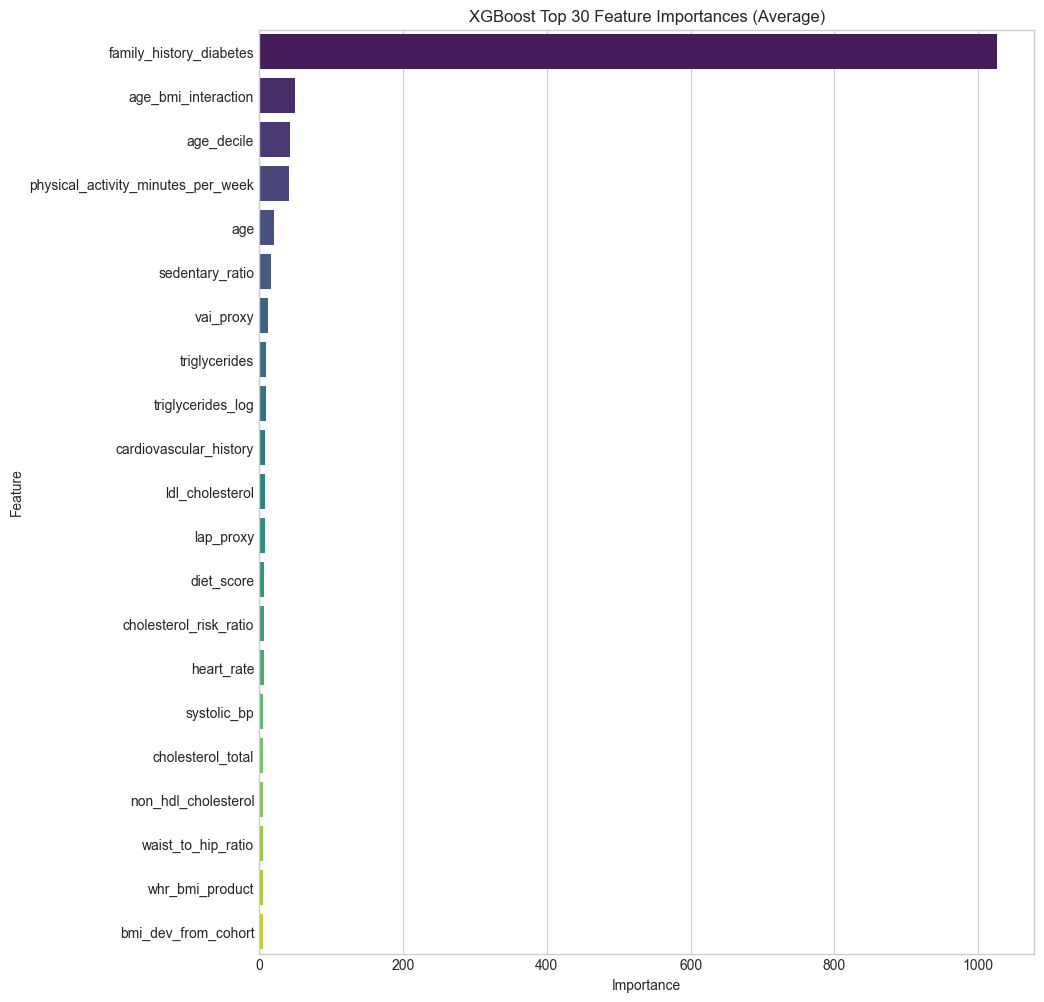

In [13]:
mviz.plot_feature_importance(models, show_values=True)

### ROC Curve (Receiver Operating Characteristic)

A plot of the **True Positive Rate** (Sensitivity) vs. the **False Positive Rate** (1 - Specificity) at every possible probability threshold (0% to 100%).

**Interpretation**  
*   **Top-Left Corner:** The perfect model. It catches 100% of diabetes cases with 0 false alarms.
*   **Diagonal Line:** Random guessing (AUC = 0.5).
*   **The Curve:** Shows the trade-off. To catch more diabetes cases (move up), we inevitably accept more false alarms (move right).
    

**What else can ROC be used for?**  
*   **Threshold Tuning:** The model outputs a probability (e.g., 0.35). Is that a "Yes" or a "No"?
    *   If this is a **Pre-Screening App** (high sensitivity needed), we pick a point high on the Y-axis (e.g., threshold 0.2), accepting that we'll flag some healthy people.
    *   If this is for **Surgery** (high precision needed), we pick a point far left on the X-axis (e.g., threshold 0.8), ensuring we only operate when very certain.
*   **Model Comparison:** In the upcoming "Model Blending/Stacking" notebook, we can plot the curves for XGBoost, CatBoost, and LightGBM on one graph. If the curves cross, one model might be better for high-sensitivity tasks while the other is better for high-precision tasks, even if their AUC is similar.

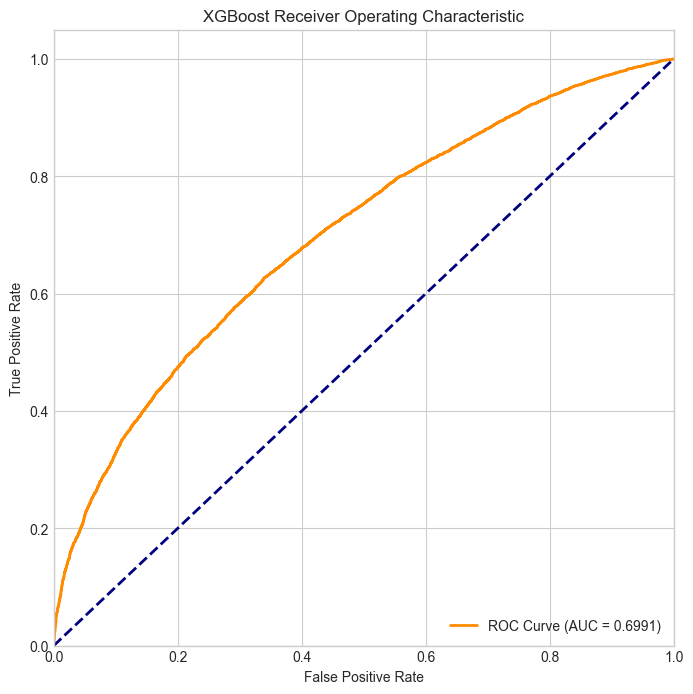

In [14]:
mviz.plot_roc_curve(y[original_mask], oof_preds[original_mask])

## Prepare Submission

In [15]:
submission_df = helper.read_sample_submission_dataset()
submission_df[TARGET] = test_preds

print('SUBMISSION')
print('==========')

print(submission_df.head(10))

SUBMISSION
       id  diagnosed_diabetes
0  700000               0.311
1  700001               0.556
2  700002               0.624
3  700003               0.267
4  700004               0.890
5  700005               0.437
6  700006               0.575
7  700007               0.879
8  700008               0.409
9  700009               0.791


In [16]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Predictions

The OOF and test predictions are saved so that they may be used for comparison of performance differences between the various models, or by a notebook exploring blending the predictions of the models using some of the tools and techniques outline by Tilii in his excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [17]:
# Ensure directory exists
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True) 

# Save OOF predictions and raw Test predictions.
# We will load these files in a separate "Blending Notebook".
oof_df = pd.DataFrame({'id': training_df.index, 'pred_xgb': oof_preds, 'target': y})
oof_df.to_csv(f'{output_dir}/xgb_oof_preds.csv', index=False)

test_pred_df = pd.DataFrame({'id': test_df.index, 'pred_xgb': test_preds})
test_pred_df.to_csv(f'{output_dir}/xgb_test_preds.csv', index=False)

print(f'Saved for Blending: {output_dir}/xgb_oof_preds.csv, {output_dir}/xgb_test_preds.csv')

Saved for Blending: predictions/xgb_oof_preds.csv, predictions/xgb_test_preds.csv
